Path exists: True
Total images found: 84371


Computing blur scores: 100%|██████████| 5000/5000 [00:43<00:00, 115.96it/s]



open:
  Total images : 2469
  Min score    : 1.1
  5th pct      : 2.3
  Median       : 19.9
  Max score    : 540.4
  Below 20     : 1237 (50.1%)
  Below 50     : 1782 (72.2%)
  Below 100    : 2170 (87.9%)

closed:
  Total images : 2531
  Min score    : 1.1
  5th pct      : 2.7
  Median       : 11.2
  Max score    : 389.6
  Below 20     : 1430 (56.5%)
  Below 50     : 1934 (76.4%)
  Below 100    : 2333 (92.2%)


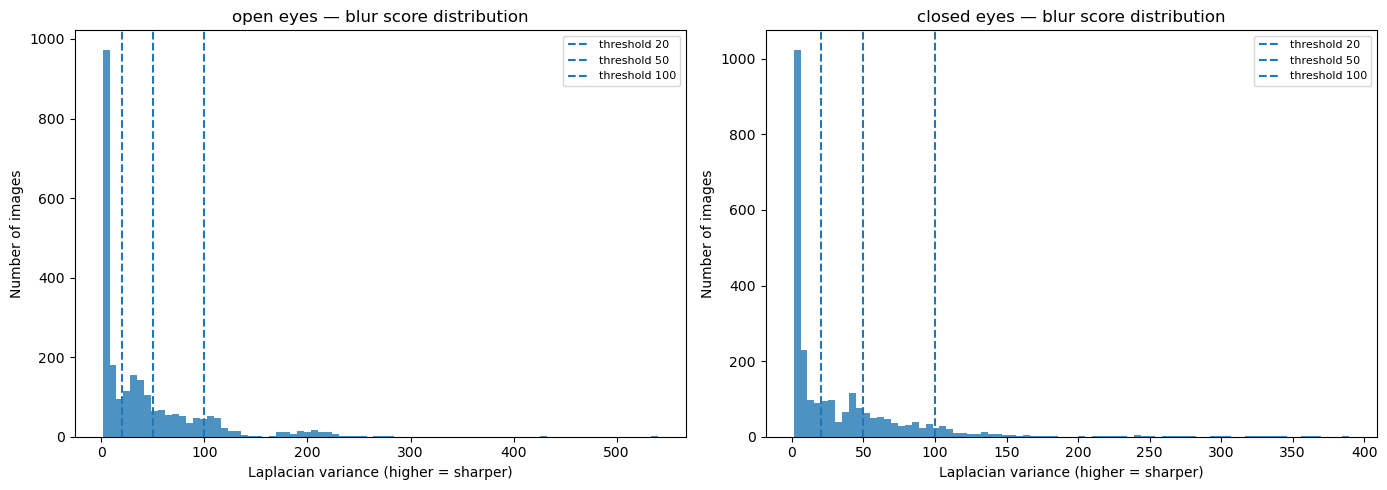

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import random

# 🔧 FIX PATH (change if needed)
PROCESSED = Path("../data/processed/train")   # update if your path is different
EXTS = {".jpg", ".jpeg", ".png"}

# ✅ Check path
print("Path exists:", PROCESSED.exists())

# ✅ Get all image files
all_files = [f for f in PROCESSED.rglob("*") if f.suffix.lower() in EXTS]
print("Total images found:", len(all_files))

if len(all_files) == 0:
    raise ValueError("❌ No images found. Check your dataset path!")

# ✅ Random sampling (max 5000)
sample = random.sample(all_files, min(5000, len(all_files)))

scores = {"open": [], "closed": []}

# 🔍 Process images
for fpath in tqdm(sample, desc="Computing blur scores"):
    img = cv2.imread(str(fpath))
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    score = cv2.Laplacian(gray, cv2.CV_64F).var()

    label = fpath.parent.name.lower()

    # ✅ Only store valid labels
    if label in scores:
        scores[label].append(score)

# 📊 Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, vals) in zip(axes, scores.items()):
    vals = np.array(vals)

    # ⚠️ Handle empty case
    if len(vals) == 0:
        print(f"\n⚠️ No data for label: {label}")
        ax.set_title(f"{label} — No data")
        continue

    ax.hist(vals, bins=80, alpha=0.8)

    ax.axvline(x=20,  linestyle="--", linewidth=1.5, label="threshold 20")
    ax.axvline(x=50,  linestyle="--", linewidth=1.5, label="threshold 50")
    ax.axvline(x=100, linestyle="--", linewidth=1.5, label="threshold 100")

    ax.set_title(f"{label} eyes — blur score distribution")
    ax.set_xlabel("Laplacian variance (higher = sharper)")
    ax.set_ylabel("Number of images")
    ax.legend(fontsize=8)

    # 📈 Stats
    p5  = np.percentile(vals, 5)
    p50 = np.percentile(vals, 50)

    print(f"\n{label}:")
    print(f"  Total images : {len(vals)}")
    print(f"  Min score    : {vals.min():.1f}")
    print(f"  5th pct      : {p5:.1f}")
    print(f"  Median       : {p50:.1f}")
    print(f"  Max score    : {vals.max():.1f}")
    print(f"  Below 20     : {(vals < 20).sum()} ({(vals < 20).mean()*100:.1f}%)")
    print(f"  Below 50     : {(vals < 50).sum()} ({(vals < 50).mean()*100:.1f}%)")
    print(f"  Below 100    : {(vals < 100).sum()} ({(vals < 100).mean()*100:.1f}%)")

# 💾 Save output
Path("outputs").mkdir(exist_ok=True)
plt.tight_layout()
plt.savefig("outputs/blur_distribution.png", dpi=150, bbox_inches="tight")
plt.show()